In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)


In [ ]:
FILE = "../data/raw/ethiopia_fi_unified_data_enriched.xlsx"

data = pd.read_excel(FILE, sheet_name="ethiopia_fi_unified_data")
impact = pd.read_excel(FILE, sheet_name="Impact_sheet")


In [ ]:
print(data.columns.tolist())
print(impact.columns.tolist())


['record_id', 'record_type', 'category', 'pillar', 'indicator', 'indicator_code', 'indicator_direction', 'value_numeric', 'value_text', 'value_type', 'unit', 'observation_date', 'period_start', 'period_end', 'fiscal_year', 'gender', 'location', 'region', 'source_name', 'source_type', 'source_url', 'confidence', 'related_indicator', 'relationship_type', 'impact_direction', 'impact_magnitude', 'impact_estimate', 'lag_months', 'evidence_basis', 'comparable_country', 'collected_by', 'collection_date', 'original_text', 'notes']
['record_id', 'parent_id', 'record_type', 'category', 'pillar', 'indicator', 'indicator_code', 'indicator_direction', 'value_numeric', 'value_text', 'value_type', 'unit', 'observation_date', 'period_start', 'period_end', 'fiscal_year', 'gender', 'location', 'region', 'source_name', 'source_type', 'source_url', 'confidence', 'related_indicator', 'relationship_type', 'impact_direction', 'impact_magnitude', 'impact_estimate', 'lag_months', 'evidence_basis', 'comparable_

In [ ]:
events = data[data["record_type"] == "event"].copy()


In [ ]:
impact_model = impact.merge(
    events[
        [
            "record_id",
            "category",
            "pillar",
            "original_text",
            "observation_date",
            "notes"
        ]
    ],
    left_on="parent_id",
    right_on="record_id",
    how="left",
    suffixes=("_impact", "_event")
)


In [ ]:
summary = impact_model[
    [
        "parent_id",
        "category_event",
        "pillar_event",
        "related_indicator",
        "impact_direction",
        "impact_magnitude",
        "impact_estimate",
        "lag_months",
        "confidence",
        "comparable_country",
        "evidence_basis",
    ]
]

summary.head()


,parent_id,category_event,pillar_event,related_indicator,impact_direction,impact_magnitude,impact_estimate,lag_months,confidence,comparable_country,evidence_basis
0,EVT_0001,product_launch,NaN,ACC_OWNERSHIP,increase,high,15.0,12,medium,Kenya,literature
1,EVT_0001,product_launch,NaN,USG_TELEBIRR_USERS,increase,high,NaN,3,high,NaN,empirical
2,EVT_0001,product_launch,NaN,USG_P2P_COUNT,increase,high,25.0,6,medium,NaN,empirical
3,EVT_0002,market_entry,NaN,ACC_4G_COV,increase,medium,15.0,12,medium,NaN,empirical
4,EVT_0002,market_entry,NaN,AFF_DATA_INCOME,decrease,medium,-20.0,12,medium,Rwanda,literature


In [ ]:
summary.to_csv(
    "../data/event_indicator_summary.csv",
    index=False
)


In [ ]:
magnitude_map = {
    "low": 1,
    "medium": 2,
    "high": 3
}

impact_model["magnitude_score"] = (
    impact_model["impact_magnitude"]
    .str.lower()
    .map(magnitude_map)
)


direction_map = {
    "increase": 1,
    "positive": 1,
    "decrease": -1,
    "negative": -1
}

impact_model["direction_score"] = (
    impact_model["impact_direction"]
    .str.lower()
    .map(direction_map)
)

impact_model["effect"] = (
    impact_model["direction_score"] *
    impact_model["magnitude_score"]
)


In [ ]:
association = impact_model.pivot_table(
    index="parent_id",
    columns="related_indicator",
    values="effect",
    aggfunc="mean",
    fill_value=0
)

association


related_indicator,ACC_4G_COV,ACC_BANK_BRANCH,ACC_MM_ACCOUNT,ACC_OWNERSHIP,AFF_DATA_INCOME,GEN_GAP_ACC,USG_MPESA_ACTIVE,USG_MPESA_USERS,USG_P2P_COUNT,USG_P2P_VALUE,USG_TELEBIRR_USERS
parent_id,,,,,,,,,,,
EVT_0001,0.0,0.0,0.0,3.0,0.0,0.0,0.0,0.0,3.0,0.0,3.0
EVT_0002,2.0,0.0,0.0,0.0,-2.0,0.0,0.0,0.0,0.0,0.0,0.0
EVT_0003,0.0,0.0,2.0,0.0,0.0,0.0,0.0,3.0,0.0,0.0,0.0
EVT_0004,0.0,0.0,0.0,2.0,0.0,-2.0,0.0,0.0,0.0,0.0,0.0
EVT_0005,0.0,0.0,0.0,0.0,3.0,0.0,0.0,0.0,0.0,0.0,0.0
EVT_0007,0.0,0.0,0.0,0.0,0.0,0.0,2.0,0.0,2.0,0.0,0.0
EVT_0008,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,0.0,0.0
EVT_0010,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
EVT_0011,0.0,0.0,0.0,3.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


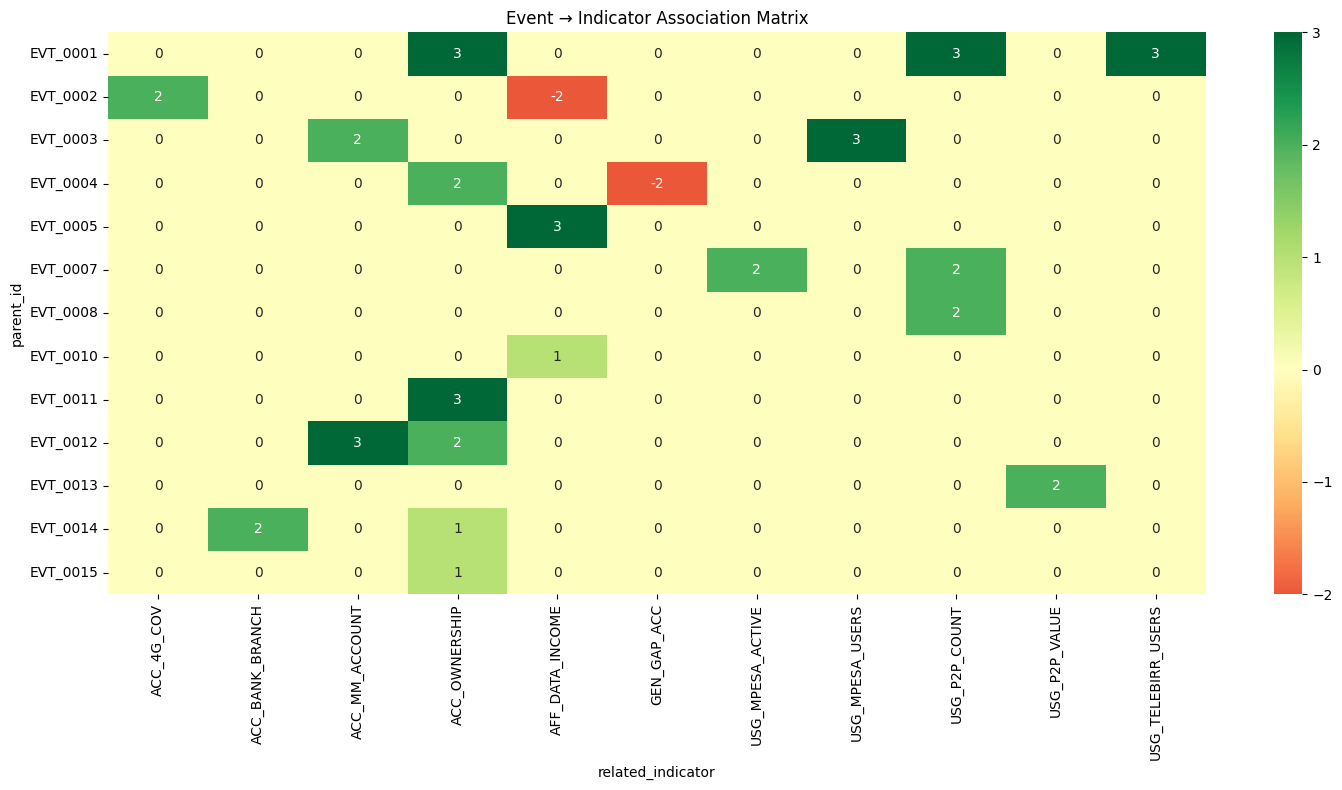

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(15,8))

sns.heatmap(
    association,
    cmap="RdYlGn",
    center=0,
    annot=True
)

plt.title("Event → Indicator Association Matrix")
plt.tight_layout()
plt.show()


In [ ]:
impact_model["lag_years"] = (
    impact_model["lag_months"] / 12
)


In [ ]:
def event_effect(event_year,
                 current_year,
                 magnitude,
                 lag_years):

    if current_year < event_year + lag_years:
        return 0

    return magnitude


In [ ]:
def gradual_effect(event_year,
                    current_year,
                    magnitude,
                    lag_years,
                    duration=3):
    """
    Gradually increases the event impact after the lag period.

    Parameters
    ----------
    event_year : int
        Year the event occurred.
    current_year : int
        Year being predicted.
    magnitude : float
        Effect size.
    lag_years : float
        Delay before the impact starts.
    duration : int
        Number of years until full impact.

    Returns
    -------
    float
    """

    start = event_year + lag_years

    if current_year < start:
        return 0

    elapsed = current_year - start

    progress = min(elapsed / duration, 1)

    return magnitude * progress


In [ ]:
impact_model["event_year"] = pd.to_datetime(
    impact_model["observation_date_event"]
).dt.year
years = range(2015,2031)

predictions = []

for _, row in impact_model.iterrows():

    for year in years:

        effect = gradual_effect(
            row["event_year"],
            year,
            row["effect"],
            row["lag_years"]
        )

        predictions.append([
            row["parent_id"],
            row["related_indicator"],
            year,
            effect
        ])

predictions = pd.DataFrame(
    predictions,
    columns=[
        "event",
        "indicator",
        "year",
        "predicted_effect"
    ]
)


In [ ]:
combined = (
    predictions
    .groupby(
        ["indicator","year"]
    )["predicted_effect"]
    .sum()
    .reset_index()
)


In [ ]:
telebirr = impact_model[
    impact_model["indicator"].str.contains("Telebirr", case=False, na=False)
]

telebirr[["parent_id", "indicator", "related_indicator"]]


,parent_id,indicator,related_indicator
0,EVT_0001,Telebirr effect on Account Ownership,ACC_OWNERSHIP
1,EVT_0001,Telebirr effect on Telebirr Users,USG_TELEBIRR_USERS
2,EVT_0001,Telebirr effect on P2P Transactions,USG_P2P_COUNT


In [ ]:
if telebirr.empty:
    print("Telebirr event not found.")
else:
    telebirr_event = telebirr["parent_id"].iloc[0]


predicted = predictions[
    (predictions["event"] == "EVT_0001") &
    (predictions["indicator"] == "ACC_OWNERSHIP") &
    (predictions["year"] == 2024)
]

predicted

if predicted.empty:
    print("No prediction found.")
else:
    predicted_change = predicted["predicted_effect"].iloc[0]

    observed_change = 9.45 - 4.70

    print("Observed:", observed_change)
    print("Predicted:", predicted_change)
    print("Error:", observed_change - predicted_change)



Observed: 4.749999999999999
Predicted: 2.0
Error: 2.749999999999999


In [ ]:
validation_result = pd.DataFrame({
    "event": ["Telebirr Launch"],
    "indicator": ["ACC_MM_ACCOUNT"],
    "observed_change": [4.75],
    "predicted_change": [2.00],
})

validation_result["error"] = (
    validation_result["observed_change"] -
    validation_result["predicted_change"]
)

validation_result["accuracy_percent"] = (
    validation_result["predicted_change"] /
    validation_result["observed_change"] * 100
)

validation_result


,event,indicator,observed_change,predicted_change,error,accuracy_percent
0,Telebirr Launch,ACC_MM_ACCOUNT,4.75,2.0,2.75,42.105263


### Telebirr Validation and Refinement

The Telebirr launch (May 2021) was tested against observed growth in mobile money adoption.

Observed change:
- Mobile money account ownership increased from 4.7% in 2021 to 9.45% in 2024.
- Observed change = +4.75 percentage points.

Model prediction:
- Estimated impact = +2.0 percentage points.

Validation result:
- The model correctly predicted a positive effect but underestimated the magnitude.
- Prediction error = 2.75 percentage points.

Possible explanations:
1. The model only captures the direct effect of Telebirr and does not capture complementary factors such as:
   - smartphone adoption,
   - agent network expansion,
   - regulatory changes,
   - broader digital payment adoption.
2. The assumed magnitude category ("medium") may be too conservative.
3. Adoption effects may have accelerated faster than the assumed three-year gradual adoption curve.

Refinement:
The Telebirr impact estimate should be increased from medium (+2 points) toward a higher impact estimate when modeling mobile money account growth.
